In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns

In [21]:
df = pd.read_csv("/content/drive/MyDrive/PROJECT/studentperformance_preprocessed.csv")

In [22]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group b,bachelor's degree,standard,none,72,72,74
1,female,group c,some college,standard,completed,69,90,88
2,female,group b,master's degree,standard,none,90,95,93
3,male,group a,associate's degree,free/reduced,none,47,57,44
4,male,group c,some college,standard,none,76,78,75


In [23]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group e,master's degree,standard,completed,88,99,95
996,male,group c,high school,free/reduced,none,62,55,55
997,female,group c,high school,free/reduced,completed,59,71,65
998,female,group d,some college,standard,completed,68,78,77
999,female,group d,some college,free/reduced,none,77,86,86


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [25]:
df.isnull()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


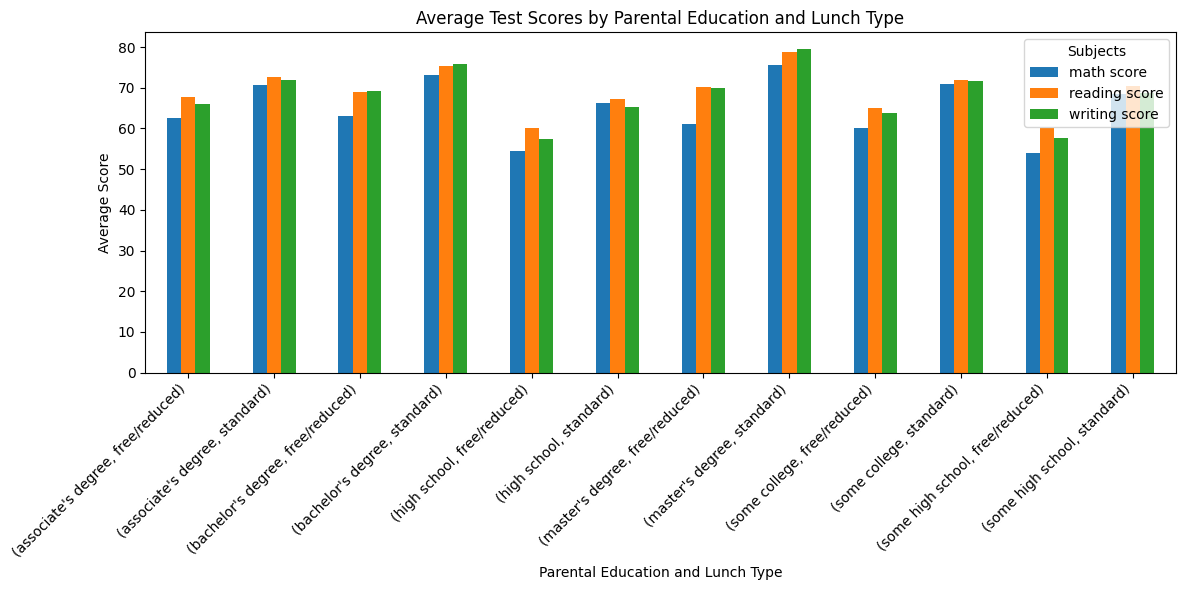

In [26]:
avg_scores = df.groupby(
    ['parental level of education', 'lunch']
)[['math score', 'reading score', 'writing score']].mean()
avg_scores.plot(kind='bar', figsize=(12,6))

plt.title("Average Test Scores by Parental Education and Lunch Type")
plt.xlabel("Parental Education and Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Subjects")
plt.tight_layout()
plt.show()

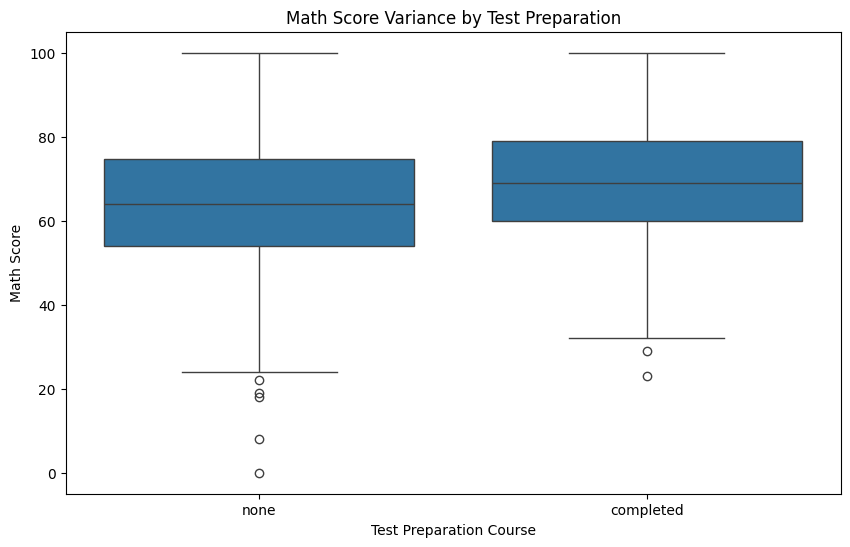

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='test preparation course',
    y='math score'
)
plt.title("Math Score Variance by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

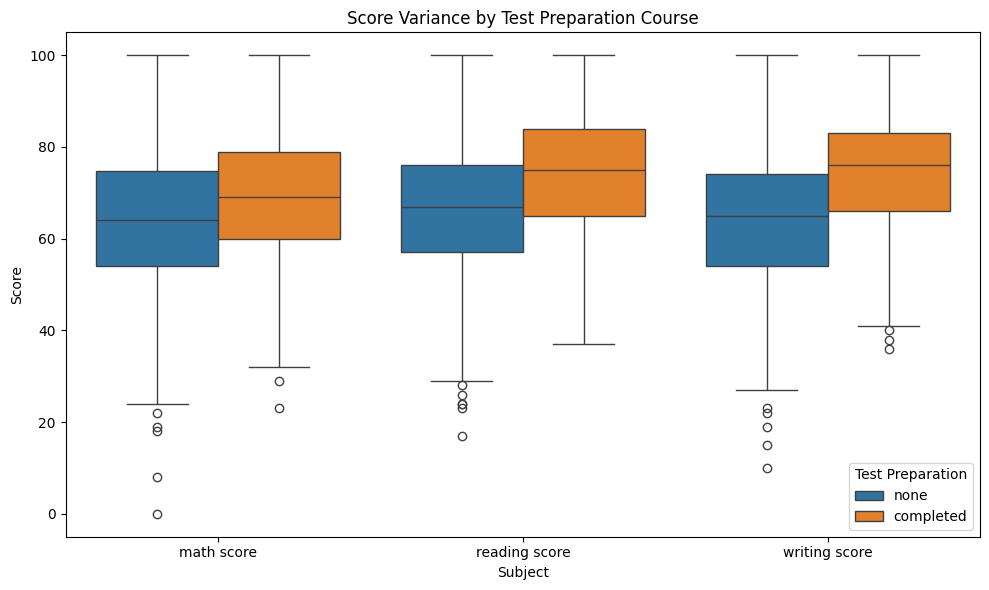

In [28]:
score_data = df.melt(
    id_vars=['test preparation course'],
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='Subject',
    value_name='Score'
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=score_data,
    x='Subject',
    y='Score',
    hue='test preparation course'
)

plt.title("Score Variance by Test Preparation Course")
plt.xlabel("Subject")
plt.ylabel("Score")
plt.legend(title="Test Preparation")
plt.tight_layout()
plt.show()

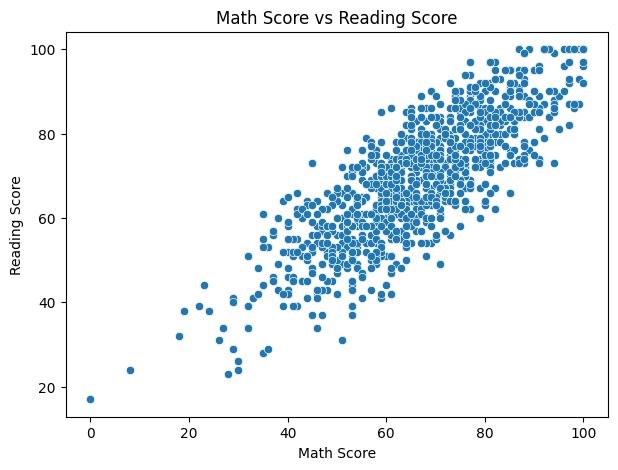

In [29]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='math score',
    y='reading score'
)

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

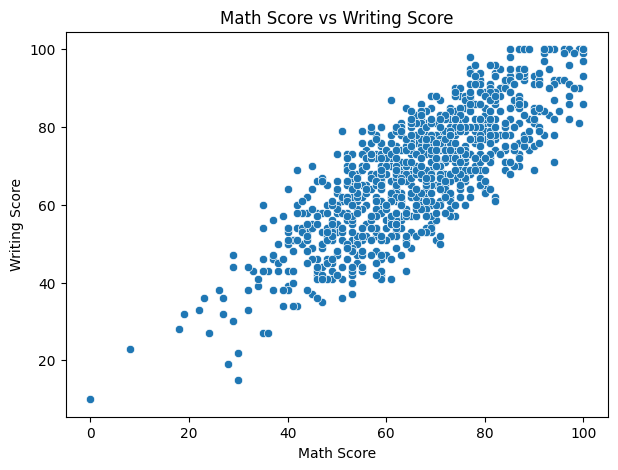

In [30]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='math score',
    y='writing score'
)

plt.title("Math Score vs Writing Score")
plt.xlabel("Math Score")
plt.ylabel("Writing Score")
plt.show()

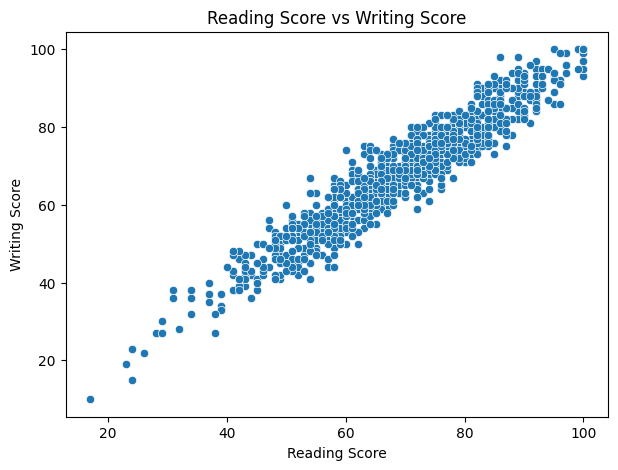

In [31]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='reading score',
    y='writing score'
)

plt.title("Reading Score vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()

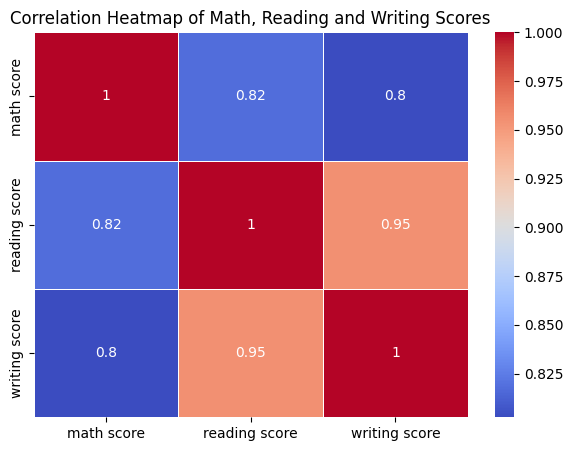

In [32]:
scores = df[['math score', 'reading score', 'writing score']]
corr = scores.corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap of Math, Reading and Writing Scores")
plt.show()